# Kriging on the Branin 2D function (R)

This notebook demonstrates basic Gaussian Process (Kriging) regression using **rlibkriging** on the classic 2D Branin test function.

Steps:
1. Install rlibkriging (run once)
2. Load rlibkriging
3. Define the Branin function and plot it
4. Build a space-filling design and evaluate it
5. Fit a `Kriging` model
6. Predict on a fine grid and plot mean + uncertainty
7. Inspect model parameters

## 0. Installation (run once)

Build the C++ core and the R binding from source.
Requires: `cmake`, a C++ compiler, and R development headers.

The script `tools/r-linux-macos/build.sh` calls `tools/linux-macos/build.sh`
to build the C++ core, then runs `make` in `bindings/R` to compile and install
**rlibkriging** into `bindings/R/Rlibs`.

In [1]:
# Run this cell once to build and install rlibkriging.
# Skip if already built (bindings/R/Rlibs/rlibkriging exists).
repo_root <- normalizePath(file.path(getwd(), "../.."), mustWork = FALSE)
rlibs     <- file.path(repo_root, "bindings", "R", "Rlibs", "rlibkriging")

if (!dir.exists(rlibs)) {
  message("Building rlibkriging from source…")
  ret <- system(paste0("cd '", repo_root, "' && bash tools/r-linux-macos/build.sh"))
  if (ret != 0) stop("Build failed — check compiler and cmake installation.")
} else {
  message("rlibkriging already built, skipping.")
}

rlibkriging already built, skipping.



## 1. Load rlibkriging

In [2]:
repo_root <- normalizePath(file.path(getwd(), "../.."), mustWork = FALSE)
lib_path  <- file.path(repo_root, "bindings", "R", "Rlibs")
library(rlibkriging, lib.loc = lib_path)


Attachement du package : ‘rlibkriging’




L'objet suivant est masqué depuis ‘package:stats’:

    kernel




Les objets suivants sont masqués depuis ‘package:base’:

    load, save




## 2. Branin function

The Branin function is a standard benchmark for surrogate modelling, defined on $[0,1]^2$
(rescaled from its canonical domain $[-5, 10] \times [0, 15]$).
It has three global minima.

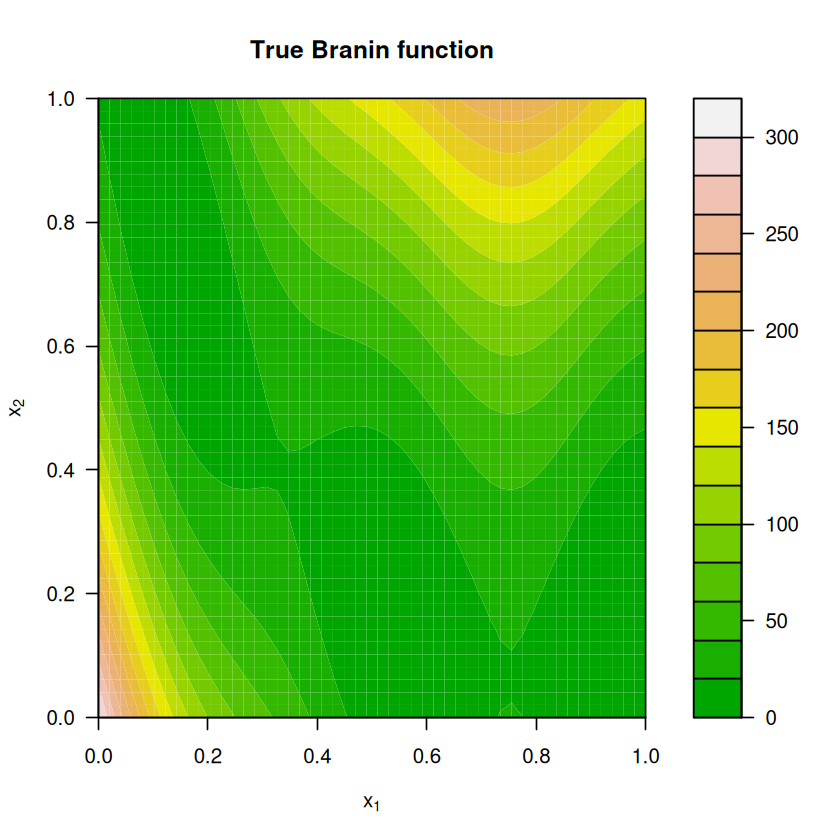

In [3]:
branin <- function(x) {
  if (!is.matrix(x)) x <- matrix(x, nrow = 1)
  x1 <- x[, 1] * 15 - 5
  x2 <- x[, 2] * 15
  (x2 - 5 / (4 * pi^2) * x1^2 + 5 / pi * x1 - 6)^2 +
    10 * (1 - 1 / (8 * pi)) * cos(x1) + 10
}

# Visualise true function on a 50x50 grid
grid_x <- seq(0, 1, length.out = 50)
grid   <- as.matrix(expand.grid(x1 = grid_x, x2 = grid_x))
z_true <- matrix(branin(grid), 50, 50)

filled.contour(
  grid_x, grid_x, z_true,
  color.palette = terrain.colors,
  main = "True Branin function",
  xlab = expression(x[1]), ylab = expression(x[2])
)

## 3. Design of experiments

We sample $n = 20$ points using a Latin Hypercube Design.

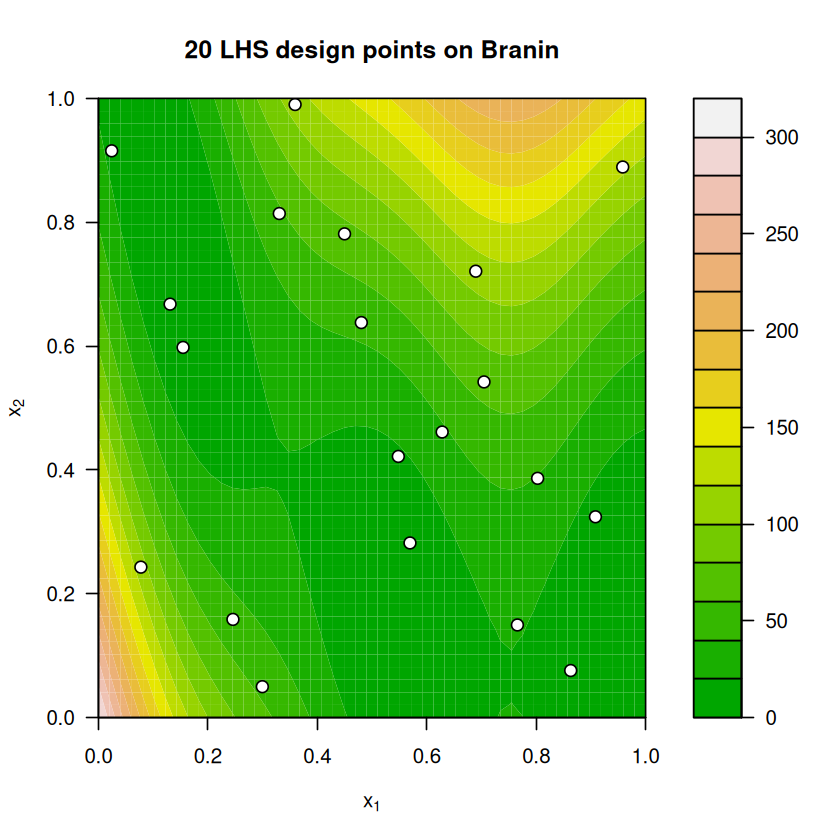

In [4]:
set.seed(42)
n <- 20
# LHS: permute uniform strata independently per dimension
lhs <- function(n, d) {
  X <- matrix(NA, n, d)
  for (j in seq_len(d))
    X[, j] <- (sample(n) - runif(n)) / n
  X
}
X <- lhs(n, 2)
y <- branin(X)

filled.contour(
  grid_x, grid_x, z_true,
  color.palette = terrain.colors,
  main = paste(n, "LHS design points on Branin"),
  xlab = expression(x[1]), ylab = expression(x[2]),
  plot.axes = {
    axis(1); axis(2)
    points(X[, 1], X[, 2], pch = 21, bg = "white", cex = 1.2)
  }
)

## 4. Fit a Kriging model

`Kriging()` fits by maximum likelihood (`objective = "LL"`).
`optim = "BFGS10"` runs 10 random restarts to avoid local optima.

In [5]:
k <- Kriging(y, X, kernel = "matern5_2", optim = "BFGS10")
print(k)

* data: 20x[0.0242894,0.9582],[0.0499215,0.990129] -> 20x[4.37475,124.256]
* trend constant (est.): 320.78
* variance (est.): 130251
* covariance:
  * kernel: matern5_2
  * range (est.): 0.802878, 2.22914
  * fit:
    * objective: LL
    * optim: BFGS10


## 5. Predict on a fine grid

`predict()` returns the posterior mean and standard deviation at new points.

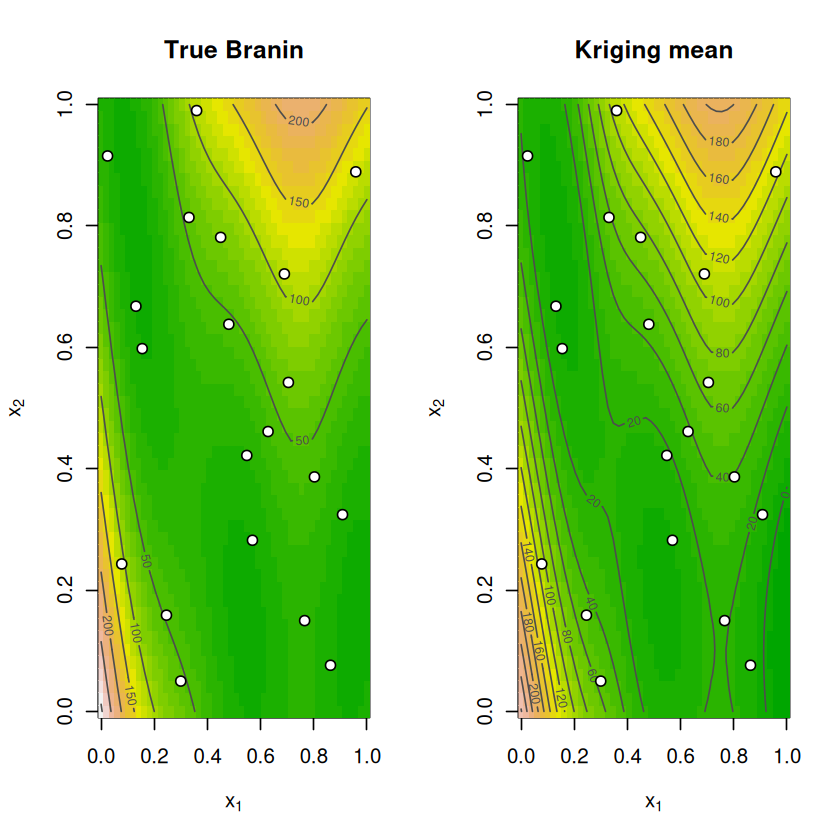

In [6]:
p <- predict(k, grid, return_stdev = TRUE)
z_mean <- matrix(p$mean,  50, 50)
z_sd   <- matrix(p$stdev, 50, 50)

# Common colour breaks to compare true vs predicted
brks <- seq(min(z_true, z_mean), max(z_true, z_mean), length.out = 30)
cols <- terrain.colors(length(brks) - 1)

par(mfrow = c(1, 2))

# --- True function ---
image(grid_x, grid_x, z_true, breaks = brks, col = cols,
      main = "True Branin", xlab = expression(x[1]), ylab = expression(x[2]))
contour(grid_x, grid_x, z_true, add = TRUE, col = "grey30", nlevels = 10)
points(X[, 1], X[, 2], pch = 21, bg = "white")

# --- Kriging mean ---
image(grid_x, grid_x, z_mean, breaks = brks, col = cols,
      main = "Kriging mean", xlab = expression(x[1]), ylab = expression(x[2]))
contour(grid_x, grid_x, z_mean, add = TRUE, col = "grey30", nlevels = 10)
points(X[, 1], X[, 2], pch = 21, bg = "white")

par(mfrow = c(1, 1))

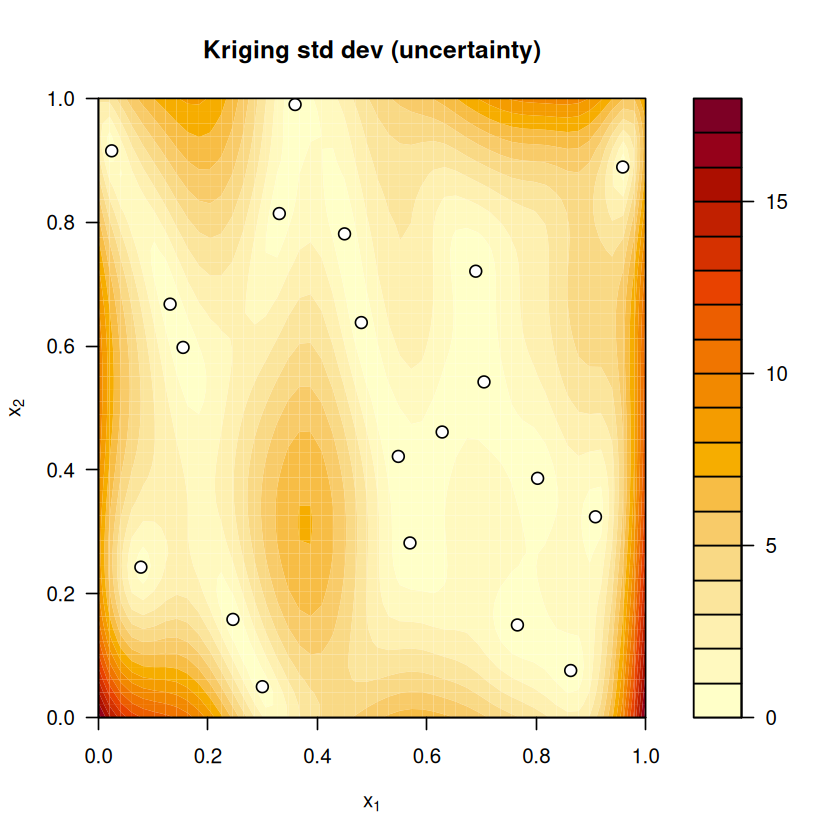

In [7]:
# Posterior standard deviation (uncertainty)
filled.contour(
  grid_x, grid_x, z_sd,
  color.palette = function(n) hcl.colors(n, "YlOrRd", rev = TRUE),
  main = "Kriging std dev (uncertainty)",
  xlab = expression(x[1]), ylab = expression(x[2]),
  plot.axes = {
    axis(1); axis(2)
    points(X[, 1], X[, 2], pch = 21, bg = "white", cex = 1.2)
  }
)

## 6. Model inspection

Key fitted parameters: length-scales $\theta$, variance $\sigma^2$, and the log-likelihood at the optimum.

In [8]:
cat("Kernel       :", k$kernel(), "\n")
cat("Theta (range):", round(k$theta(), 4), "\n")
cat("Sigma2       :", round(k$sigma2(), 4), "\n")
cat("LogLikelihood:", round(k$logLikelihood(), 4), "\n")

Kernel       : matern5_2 


Theta (range): 0.8029 2.2291 


Sigma2       : 130251.1 


LogLikelihood: -85.0978 


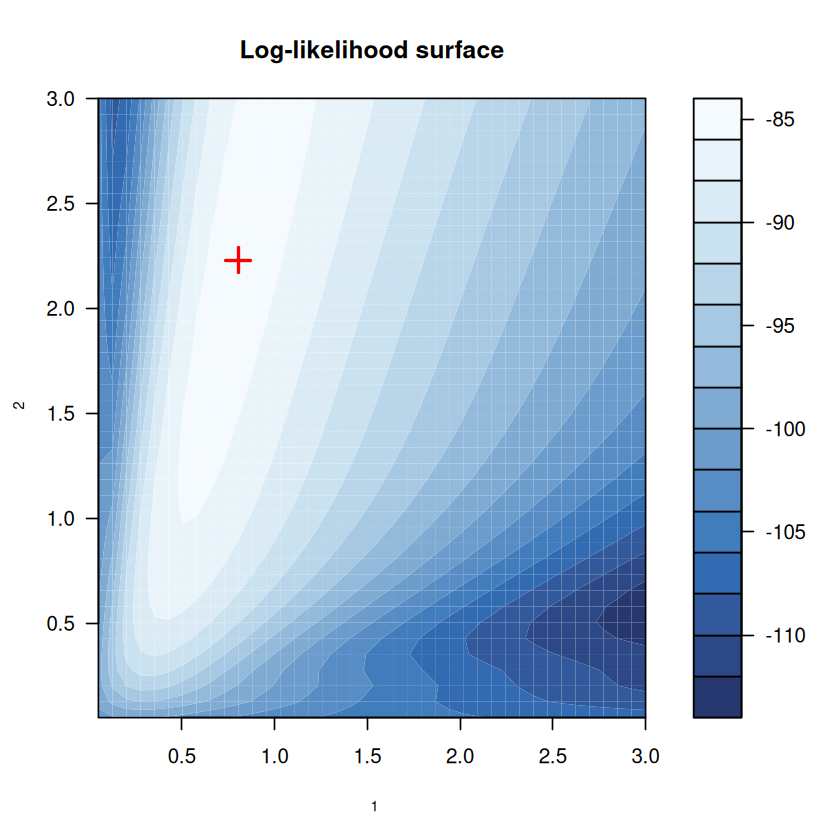

In [9]:
# Log-likelihood surface as a function of the two length-scales
theta_grid <- seq(0.05, 3, length.out = 40)
ll_mat <- outer(
  theta_grid, theta_grid,
  Vectorize(function(t1, t2) k$logLikelihoodFun(c(t1, t2))$logLikelihood)
)

filled.contour(
  theta_grid, theta_grid, ll_mat,
  color.palette = function(n) hcl.colors(n, "Blues"),
  main = "Log-likelihood surface",
  xlab = expression(theta[1]), ylab = expression(theta[2]),
  plot.axes = {
    axis(1); axis(2)
    points(k$theta()[1], k$theta()[2], pch = 3, lwd = 2, col = "red", cex = 2)
  }
)